# Yield Model Calculator for W2W hybrid bonding
#### Author: Zhichao Chen
#### Date: Aug 25, 2025
#### Description: YAP+ (pad-layout-aware yield analysis)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from utils.util import *
import os
import time
import matplotlib.pyplot as plt
from assembly_yield_calculator import Pad_Yield_Map_Generator
from utils.util import convert_3dblox_to_pad_bitmap

p_max (Pa) = -0.0
p_max (Pa) = 82298976.34903029
p_max (Pa) = 164597952.69806057
p_max (Pa) = 246896929.04709092
p_max (Pa) = 329195905.39612114


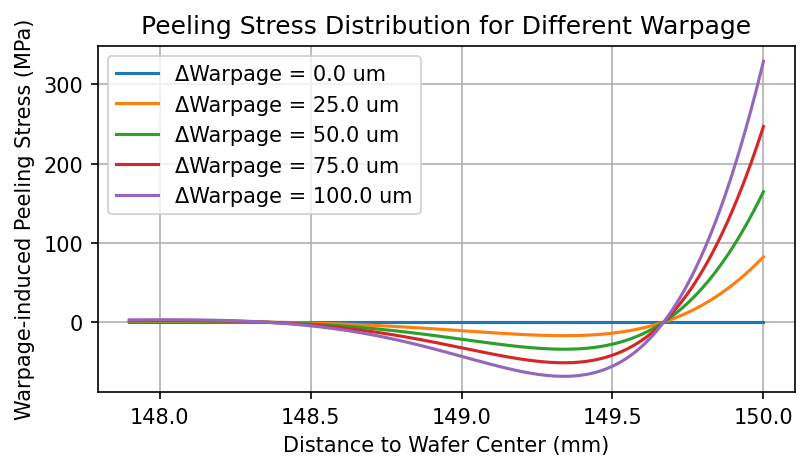

In [14]:
'''
The Suhir model is adapted from the paper: Interfacial Stresses in a Bi-material Assembly with a Compliant Bonding Layer
Paper link: https://iopscience.iop.org/article/10.1088/0022-3727/41/11/115504
This model can be used to calculate the warpage-induced peeling stress across the wafer/die.
'''

# Input parameters (all in SI units)
v1 = 0.28       # Poisson's ratio of bottom layer
v2 = 0.28       # Poisson's ratio of top layer
h1 = 775e-6 # Bottom layer thickness [m] (from Table 1 in paper: https://ieeexplore.ieee.org/document/9026578/)
h2 = 775e-6 # Top layer thickness [m]
E1 = 131e9  # Bottom layer Young's modulus [Pa]
E2 = 131e9  # Top layer Young's modulus [Pa]
K = 1 / ((1-v1)*h1/(3*E1) + (1-v2)*h2/(3*E2))
D1 = E1 * h1**3 / (12 * (1 - v1**2))  # Bottom layer bending stiffness
D2 = E2 * h2**3 / (12 * (1 - v2**2))  # Top layer bending stiffness


warpage1_init = 0e-6  # The initial warpage of the bottom layer [m]
warpage2_init = 20e-6  # The initial warpage of the top layer [m]
warpage1_anneal = 10e-6  # The warpage increment during annealing [m]
warpage2_anneal = 10e-6  # The warpage increment during annealing [m]
R = 150e-3  # Layer radius [m]
kappa1 = 2 * (warpage1_init + warpage1_anneal) / R**2  # Bottom layer curvature [1/m]
kappa2 = 2 * (warpage2_init + warpage2_anneal) / R**2  # Top layer curvature [1/m]
kappa = (D1 * kappa1 + D2 * kappa2) / (D1 + D2) # Neutral axis curvature [1/m]
M = -D1 * D2 / (D1 + D2) * (kappa1 - kappa2)  # Bending moment per unit width [Nm]
# Calculate beta in Eq. 33 in the referenced paper
beta = ((K * (D1 + D2)) / (4 * D1 * D2)) ** 0.25

npts_plot = 500         # Number of points for plotting



def p_max(K, M, beta, D1):
    '''Calculate the maximum peeling stress (typically at the edge)'''
    return K * M / (2 * beta * D1)

def p_loc(x):
    '''Calculate the peeling stress at location x from the wafer/die center'''
    term1 = p_max(K, M, beta, D1)
    print("p_max (Pa) =", term1)
    term2 = np.exp(-beta * (R - x)) * (np.cos(beta * (R - x)) - np.sin(beta * (R - x)))
    return term1 * term2

# Plot peeling stress distribution for different warpage values
x = np.linspace(0.986*R, R, npts_plot)
warpage_array = np.linspace(0, 100e-6, 5)
plt.figure(figsize=(6, 3), dpi=150)
for warpage in warpage_array:
    kappa1 = 2 * 0 / R**2  # Bottom layer curvature [1/m]
    kappa2 = 2 * warpage / R**2  # Top layer curvature [1/m]
    # print("kappa1 (1/m) =", kappa1)
    # print("kappa2 (1/m) =", kappa2)
    # print("D1 (Nm) =", D1)
    # print("D2 (Nm) =", D2)
    # print("K (N/m^3) =", K)
    # print("beta (1/m) =", beta)
    kappa = (D1 * kappa1 + D2 * kappa2) / (D1 + D2) # Neutral axis curvature [1/m]
    M = - D1 * D2 / (D1 + D2) * (kappa1 - kappa2)  # Bending moment per unit width [Nm]
    # print("M (Nm) =", M)
    p_loc_array = p_loc(x) / 1e6
    # print(max(p_loc_array))
    plt.plot(x*1e3, p_loc_array, label=f'ΔWarpage = {warpage*1e6:.1f} um')
plt.xlabel('Distance to Wafer Center (mm)')
plt.ylabel('Warpage-induced Peeling Stress (MPa)')
plt.title('Peeling Stress Distribution for Different Warpage')
plt.legend()
plt.grid()
plt.show()


redundant_net_to_bumpids: {'NC': {0, 1, 2, 3072, 15883, 15884, 15885, 12815, 2576, 6676, 10262, 4632, 4633, 12319, 2080, 2081, 6183, 4136, 6184, 14375, 11824, 563, 564, 7731, 7732, 8251, 3645, 11331, 9287, 9288, 2130, 13395, 10836, 87, 88, 89, 90, 6233, 14947, 14948, 15971, 15972, 15973, 15974, 7793, 1142, 1143, 9337, 3198, 13444, 7301, 10885, 5261, 2702, 2703, 5262, 8845, 6810, 12445, 12446, 8355, 14501, 4262, 4263, 15525, 15526, 175, 176, 177, 9914, 699, 16059, 16060, 16061, 5311, 2752, 11457, 11458, 14017, 16062, 6859, 4815, 15584, 4324, 12010, 1771, 1772, 9963, 14066, 3827, 5885, 7425, 7426, 8449, 3332, 11011, 13570, 263, 264, 265, 8970, 8971, 13074, 13075, 16147, 15130, 1821, 10530, 14635, 1325, 5934, 15661, 15662, 3381, 834, 13124, 6983, 4941, 4942, 10579, 7516, 8540, 351, 352, 353, 354, 2401, 6501, 10087, 12136, 12137, 14192, 3953, 3954, 11640, 9596, 9597, 8574, 13696, 13697, 11145, 2450, 6550, 15256, 15257, 4506, 1451, 1452, 6059, 9646, 13746, 3507, 15794, 8117, 7606, 15795, 15

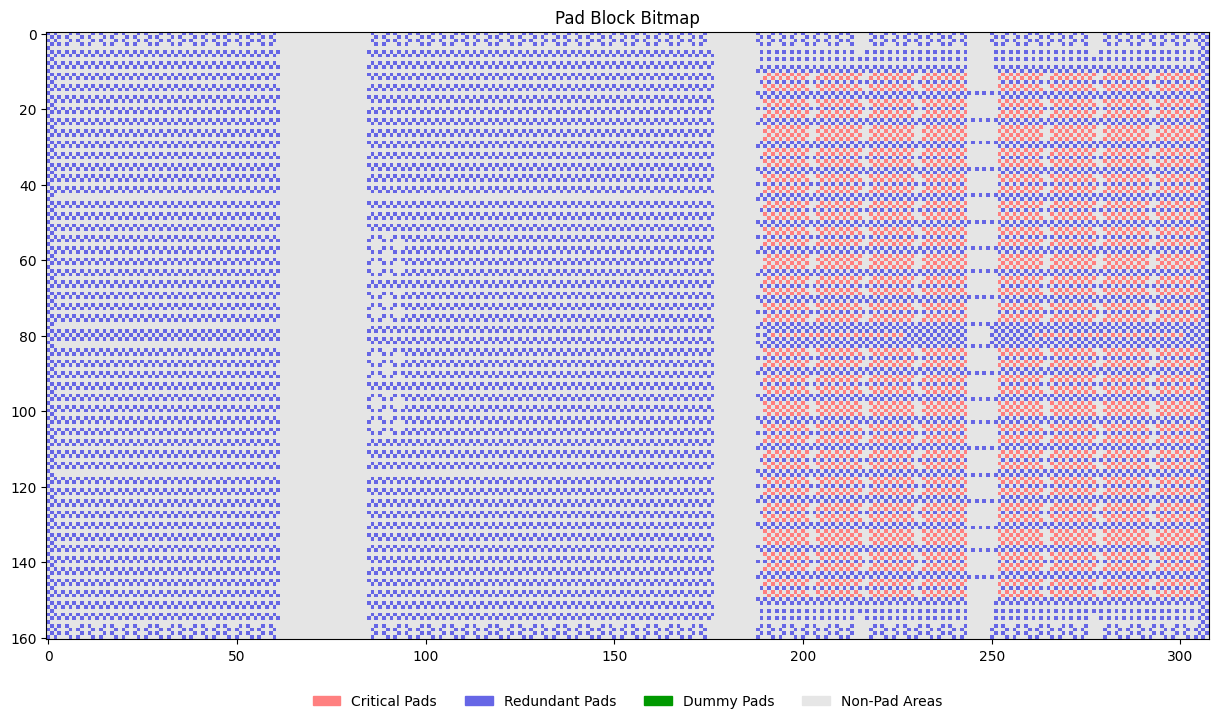

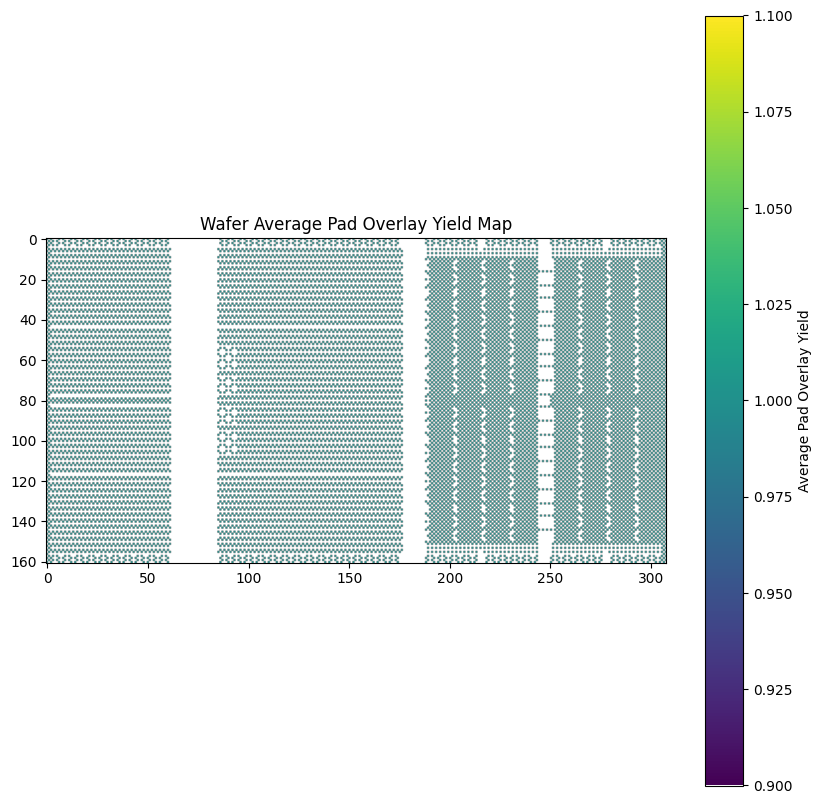

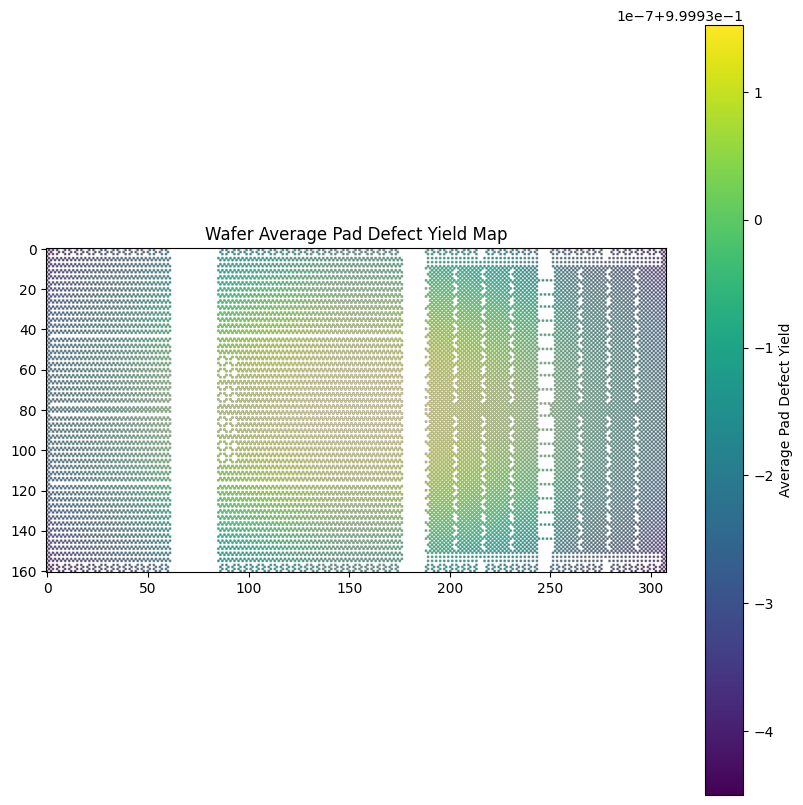

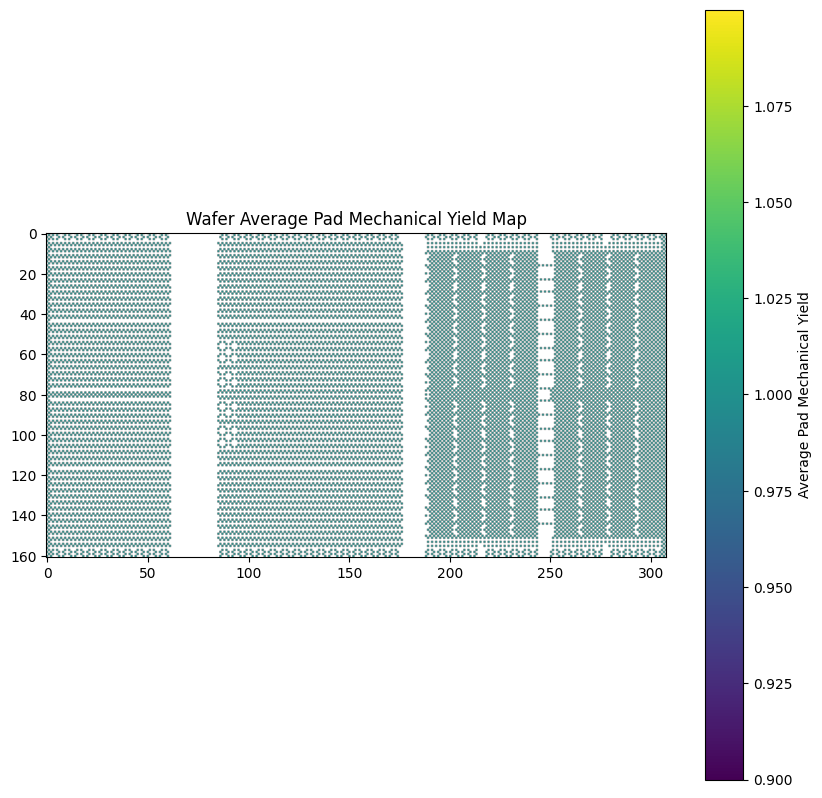

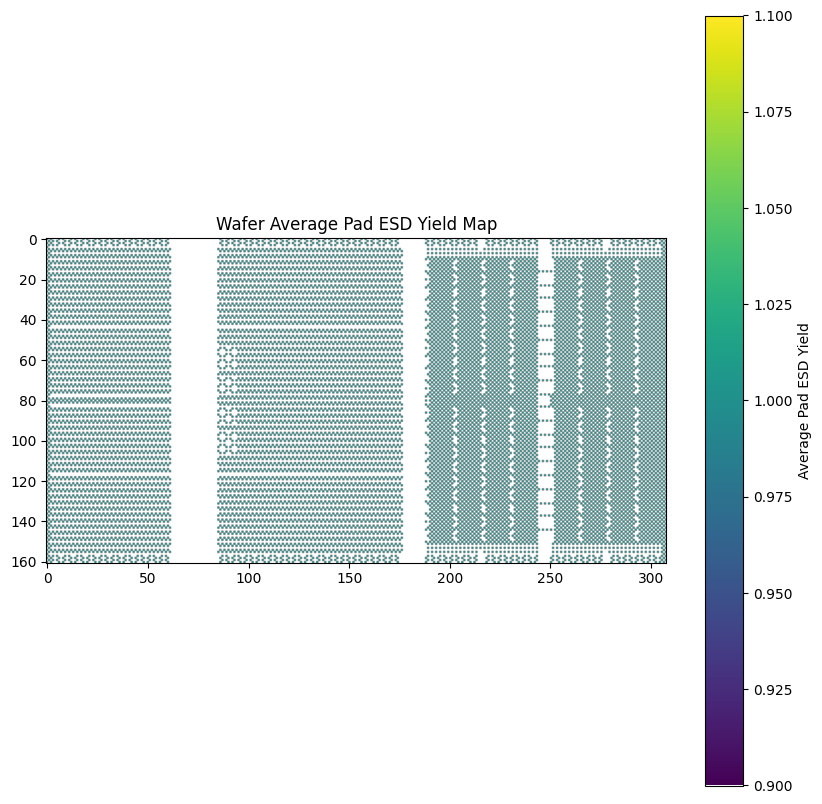

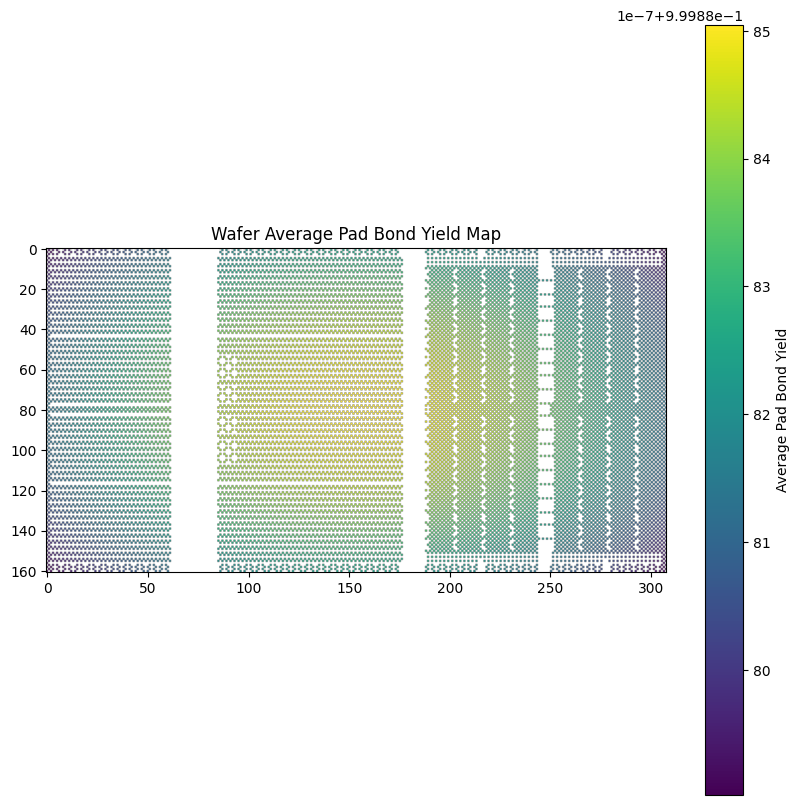

In [ ]:
# Load configuration
cfg = load_modeling_config(path='configs/HBM_footprint_A_config.yaml', 
                     mode='w2w_modeling',
                     debug=False)
if not os.path.exists('output/' + cfg.DESIGN):
    os.makedirs('output/' + cfg.DESIGN)

# Update above parameters in the configuration
update_config_items(cfg=cfg, mode='w2w_modeling')

pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                            blox_bmap_path=cfg.INPUT_DIR + cfg.DESIGN + '.bmap',
                                            criticality_path=cfg.INPUT_DIR + cfg.DESIGN + '_criticality.txt',
                                            pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)

start_time = time.time()
# Calculate the yield
Pad_Yield_Map_Generator(
    cfg=cfg, 
    pad_bitmap_collection=pad_bitmap_collection,
)